# STSA-Net for Gymnastic Exercise Recognition

This notebook implements a transformer-based network using **STSA-Net (Spatio-Temporal Self-Attention Network)** blocks for recognizing gymnastic exercises from skeleton data.

## Overview

The STSA-Net architecture processes skeleton sequences to recognize different types of gymnastic exercises. It uses:
- **Spatial Attention**: Captures relationships between joints within each frame
- **Temporal Attention**: Captures temporal dependencies across frames for each joint
- **Feed-Forward Networks**: Processes features after attention
- **Positional Embeddings**: Learns spatial and temporal position information

## Input Format

The model expects skeleton sequences of shape `(B, T, J, D)` where:
- `B`: Batch size
- `T`: Number of time frames (300)
- `J`: Number of joints (17, COCO format)
- `D`: Joint dimensions (3 for x, y, z coordinates)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

# Import model and utilities from src
from STSANet import STSANet
from src import (
    GymnasticExerciseDataset,
    train_epoch,
    validate,
    TrainingHistory,
    Config,
    plot_training_curves,
    plot_confusion_matrix,
)

# Set device - prioritize GPU
print("Checking for GPU availability...")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
    print(f"✓ GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    device = torch.device('cpu')
    print("⚠ CUDA not available - using CPU")
    print("To enable GPU support:")
    print("  1. Ensure you have an NVIDIA GPU with CUDA support")
    print("  2. Install CUDA-enabled PyTorch:")
    print("     pip uninstall torch torchvision")
    print("     pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118")

print(f"\nUsing device: {device}")

Checking for GPU availability...
PyTorch version: 2.6.0+cu124
CUDA available: True
✓ GPU detected: NVIDIA GeForce RTX 3090
✓ CUDA version: 12.4
✓ GPU memory: 24.00 GB

Using device: cuda


## Configuration

We use a centralized configuration class to manage all hyperparameters. This makes it easy to experiment with different settings.


In [2]:
# Load configuration
cfg = Config()

# Display key parameters
print("Model Configuration:")
print(f"  Time frames (T): {cfg.T}")
print(f"  Joints (J): {cfg.NUM_JOINTS}")
print(f"  Joint dim (D): {cfg.JOINT_DIM}")
print(f"  Hidden dim (H): {cfg.H}")
print(f"  Classes: {cfg.NUM_CLASSES}")
print(f"  STSA blocks: {cfg.NUM_BLOCKS}")
print(f"\nTraining Configuration:")
print(f"  Batch size: {cfg.BATCH_SIZE}")
print(f"  Learning rate: {cfg.LEARNING_RATE}")
print(f"  Epochs: {cfg.NUM_EPOCHS}")

Model Configuration:
  Time frames (T): 300
  Joints (J): 17
  Joint dim (D): 3
  Hidden dim (H): 256
  Classes: 5
  STSA blocks: 8

Training Configuration:
  Batch size: 16
  Learning rate: 0.0001
  Epochs: 50


## Dataset

We use a **synthetic dataset** that generates skeleton sequences with distinct motion patterns for each exercise type. The dataset is implemented in `src/dataset.py` and includes 5 exercise classes:

1. **Jumping Jacks** - Arms move up/down, legs spread/close
2. **Squats** - Body moves down and up
3. **Arm Circles** - Arms rotate in circular motion
4. **Lunges** - Alternating leg forward movement
5. **Push-ups** - Body moves up and down in horizontal position


In [ ]:
# Create datasets
train_dataset = GymnasticExerciseDataset(
    num_samples=cfg.TRAIN_SAMPLES,
    T=cfg.T,
    J=cfg.NUM_JOINTS,
    D=cfg.JOINT_DIM,
    num_classes=cfg.NUM_CLASSES,
    split='train'
)

val_dataset = GymnasticExerciseDataset(
    num_samples=cfg.VAL_SAMPLES,
    T=cfg.T,
    J=cfg.NUM_JOINTS,
    D=cfg.JOINT_DIM,
    num_classes=cfg.NUM_CLASSES,
    split='val'
)

test_dataset = GymnasticExerciseDataset(
    num_samples=cfg.TEST_SAMPLES,
    T=cfg.T,
    J=cfg.NUM_JOINTS,
    D=cfg.JOINT_DIM,
    num_classes=cfg.NUM_CLASSES,
    split='test'
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)

print('Dataset sizes:')
print(f'  Train: {len(train_dataset)} samples')
print(f'  Val: {len(val_dataset)} samples')
print(f'  Test: {len(test_dataset)} samples')

# Verify data shape
sample_data, sample_label = train_dataset[0]
print(f'\nSample data shape: {sample_data.shape}')
print(f'Sample label: {sample_label.item()} ({cfg.CLASS_NAMES[sample_label.item()]})')

Dataset sizes:
  Train: 800 samples
  Val: 100 samples
  Test: 100 samples

Sample data shape: torch.Size([300, 17, 3])
Sample label: 0 (Jumping Jacks)


## Model Initialization

We initialize the STSA-Net model with the configuration parameters. The model architecture consists of:
- Input embedding layer (joint coordinates → hidden dimension)
- Learnable positional embeddings (spatial and temporal)
- Stack of STSA blocks (spatial + temporal attention + FFN)
- Global average pooling and classification head


In [ ]:
# Initialize model
model = STSANet(
    T=cfg.T,
    J=cfg.NUM_JOINTS,
    D=cfg.JOINT_DIM,
    H=cfg.H,
    num_classes=cfg.NUM_CLASSES,
    num_heads=cfg.NUM_HEADS,
    dropout=cfg.DROPOUT,
    ffn_mult=cfg.FFN_MULT,
    num_blocks=cfg.NUM_BLOCKS
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model parameters:')
print(f'  Total: {total_params:,}')
print(f'  Trainable: {trainable_params:,}')

# Test forward pass
model.eval()
with torch.no_grad():
    test_input = torch.randn(2, cfg.T, cfg.NUM_JOINTS, cfg.JOINT_DIM).to(device)
    test_output = model(test_input)
    print('\nForward pass test:')
    print(f'  Input shape: {test_input.shape}')
    print(f'  Output shape: {test_output.shape}')

Model parameters:
  Total: 8,515,589
  Trainable: 8,515,589

Forward pass test:
  Input shape: torch.Size([2, 300, 17, 3])
  Output shape: torch.Size([2, 5])


## Training Setup

We use:
- **Loss function**: CrossEntropyLoss (standard for multi-class classification)
- **Optimizer**: AdamW with weight decay
- **Scheduler**: Cosine annealing learning rate schedule
- **History tracking**: TrainingHistory class to track metrics


In [5]:
# Setup loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.NUM_EPOCHS)

# Initialize training history
history = TrainingHistory()

print('Training setup complete!')

Training setup complete!


## Training

The training loop uses the functions from `src/training.py`:
- `train_epoch()`: Trains the model for one epoch
- `validate()`: Evaluates the model on validation set
- `TrainingHistory`: Tracks metrics across epochs

We save the best model based on validation accuracy.


In [6]:
# Training loop
best_val_acc = 0

for epoch in range(cfg.NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{cfg.NUM_EPOCHS}')
    print('-' * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update learning rate
    scheduler.step()
    
    # Update history
    history.update(train_loss, train_acc, val_loss, val_acc)
    
    # Print metrics
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print(f'Learning Rate: {scheduler.get_last_lr()[0]:.6f}')
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'✓ New best model saved! (Val Acc: {val_acc:.2f}%)')


Epoch 1/50
--------------------------------------------------


Validating: 100%|██████████| 7/7 [00:01<00:00,  6.39it/s]


Train Loss: 1.0992, Train Acc: 47.88%
Val Loss: 0.8044, Val Acc: 53.00%
Learning Rate: 0.000100
✓ New best model saved! (Val Acc: 53.00%)

Epoch 2/50
--------------------------------------------------


Validating: 100%|██████████| 7/7 [00:01<00:00,  6.37it/s]


Train Loss: 0.7237, Train Acc: 68.75%
Val Loss: 0.4165, Val Acc: 82.00%
Learning Rate: 0.000100
✓ New best model saved! (Val Acc: 82.00%)

Epoch 3/50
--------------------------------------------------


...

Train Loss: 0.0005, Train Acc: 100.00%
Val Loss: 0.0003, Val Acc: 100.00%
Learning Rate: 0.000000

Epoch 49/50
--------------------------------------------------


Validating: 100%|██████████| 7/7 [00:01<00:00,  5.96it/s]


Train Loss: 0.0005, Train Acc: 100.00%
Val Loss: 0.0003, Val Acc: 100.00%
Learning Rate: 0.000000

Epoch 50/50
--------------------------------------------------


Validating: 100%|██████████| 7/7 [00:01<00:00,  6.23it/s]

Train Loss: 0.0005, Train Acc: 100.00%
Val Loss: 0.0003, Val Acc: 100.00%
Learning Rate: 0.000000


## Training Curves

Visualize the training progress to monitor for overfitting and convergence.


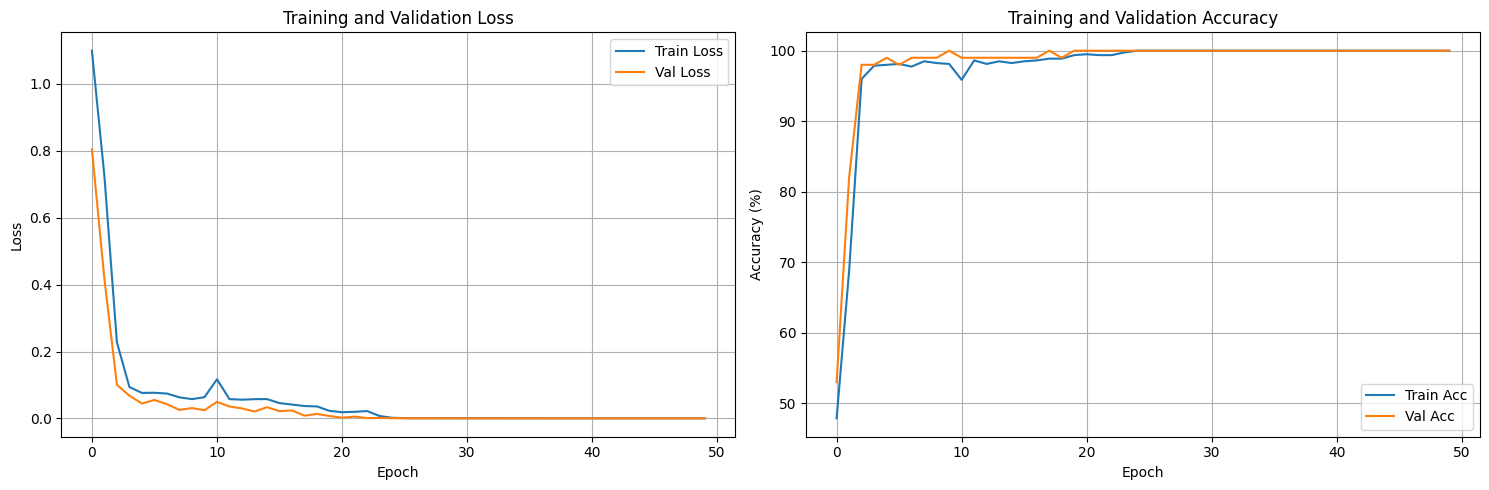

In [7]:
plot_training_curves(history)

## Evaluation

Evaluate the best model on the test set and generate detailed metrics including classification report and confusion matrix.


In [8]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Evaluate on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=cfg.CLASS_NAMES))

Test Accuracy: 97.00%

Classification Report:
               precision    recall  f1-score   support

Jumping Jacks       1.00      1.00      1.00        20
       Squats       0.90      0.95      0.93        20
  Arm Circles       1.00      1.00      1.00        20
       Lunges       1.00      1.00      1.00        20
     Push-ups       0.95      0.90      0.92        20

     accuracy                           0.97       100
    macro avg       0.97      0.97      0.97       100
 weighted avg       0.97      0.97      0.97       100



## Confusion Matrix

Visualize the confusion matrix to see which classes are being confused with each other.


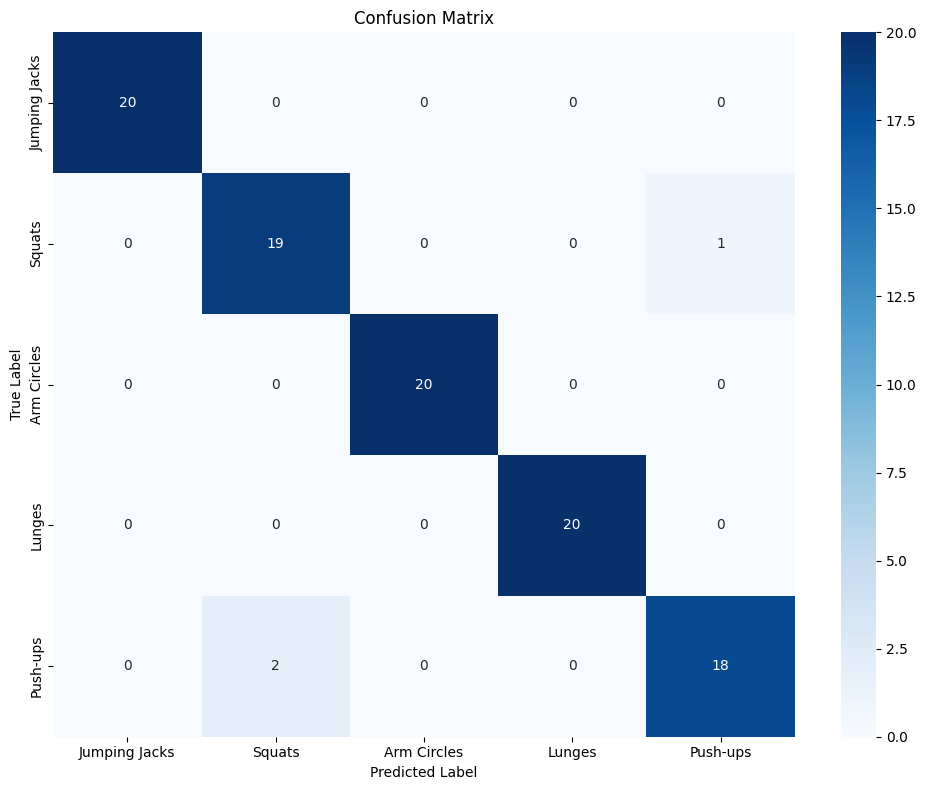

In [9]:
cm = plot_confusion_matrix(all_labels, all_preds, cfg.CLASS_NAMES)

## Summary

This implementation demonstrates the STSA-Net architecture for skeleton-based action recognition. Key features:

### Architecture Components
1. **Spatial Attention Block**: Processes joint relationships within each frame
2. **Temporal Attention Block**: Captures temporal dependencies across frames
3. **STSA Block**: Combines spatial and temporal attention with feed-forward networks
4. **Positional Embeddings**: Learnable encodings for spatial and temporal positions

### Results
The model successfully learns to distinguish between different gymnastic exercises based on their unique motion patterns. The synthetic dataset provides a good testbed for evaluating the architecture's ability to capture spatio-temporal relationships in skeleton sequences.

### Next Steps
- Try with real skeleton data (e.g., from pose estimation on video)
- Experiment with different numbers of STSA blocks
- Adjust hyperparameters for your specific use case
- Add data augmentation for better generalization
